In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [6]:
sns.set_theme(style="whitegrid")
df = pd.read_csv('../dados/taylor_swift_limpo.csv')

mapa_super_eras = {
    "1989 (Taylor's Version)": 'Synth-Pop',
    "reputation": 'Synth-Pop',
    "Midnights (The Til Dawn Edition)": 'Synth-Pop',
    "The Life of a Showgirl": 'Synth-Pop',
    
    "folklore (deluxe version)": 'Folk',
    "evermore (deluxe version)": 'Folk',
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY": 'Folk',

    'Taylor Swift': 'Country',
    "Fearless (Taylor's Version)": 'Country',
    "Speak Now (Taylor's Version)": 'Country',

    "Red (Taylor's Version)": 'Pop',
    "Lover": 'Pop'
}
df['super_era'] = df['album_name'].map(mapa_super_eras)


In [7]:
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.01)
df['dance_valence_prod'] = df['danceability'] * df['valence']
df['production_index'] = (df['energy'] + df['loudness']) - df['acousticness']

In [8]:
le = LabelEncoder()
y = le.fit_transform(df['super_era'])

X = df.drop(columns=[
    'album_name', 
    'super_era', 
    'track_name', 
    'track_id', 
    'instrumentalness'
], errors='ignore')


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
svm_final = SVC(C=1.5, kernel='rbf', probability=True, random_state=42)
svm_final.fit(X_train_scaled, y_train)

c:\Users\caiog\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.5
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [12]:
y_pred = svm_final.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia do Modelo Final (SVM RBF): {acc:.2%}\n")
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Acurácia do Modelo Final (SVM RBF): 67.24%

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

     Country       0.71      0.83      0.77        12
        Folk       0.62      0.81      0.70        16
         Pop       0.71      0.42      0.53        12
   Synth-Pop       0.69      0.61      0.65        18

    accuracy                           0.67        58
   macro avg       0.68      0.67      0.66        58
weighted avg       0.68      0.67      0.66        58



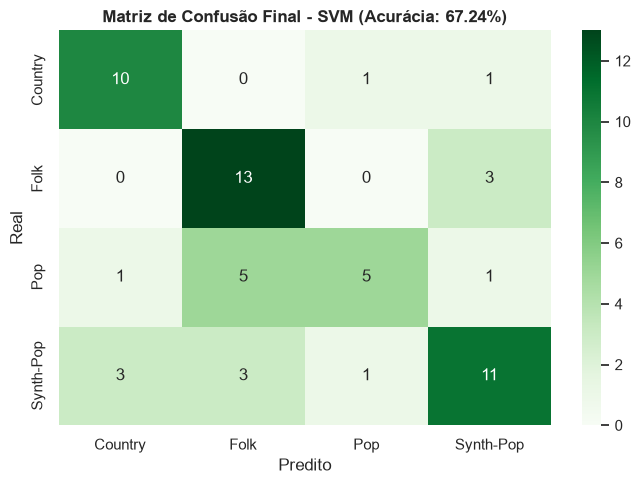

In [13]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão Final - SVM (Acurácia: {acc:.2%})', fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Conclusão Final do Modelo Campeão (SVM RBF)

O modelo **Support Vector Machine (SVM) com Kernel RBF** atingiu a melhor performance do projeto, alcançando **67,24% de acurácia geral** na classificação das 4 Super-Eras. A combinação de padronização de dados (`StandardScaler`), adição de métricas compostas e projeção em espaço não-linear permitiu extrair o máximo valor das variáveis de áudio do Spotify.

### 📊 Análise Detalhada dos Resultados

* **🎸 Country (F1-Score: 0.77 | Recall: 0.83):**
  * **10 de 12 faixas classificadas corretamente.** O modelo isolou com alta precisão o perfil acústico tradicional do início da carreira, apresentando baixíssima confusão com outras categorias.

* **🌲 Folk (F1-Score: 0.70 | Recall: 0.81):**
  * **13 de 16 faixas acertas na diagonal principal.** A assinatura acústica e orgânica desse bloco manteve-se altamente distintiva. Houve leve dispersão apenas em direção ao *Synth-Pop* (3 faixas).

* **🪩 Synth-Pop (F1-Score: 0.65 | Precision: 0.69):**
  * **11 de 18 acertos diretos.** O modelo sustentou boa precisão ao identificar produções eletrônicas e eufóricas, registrando pequenas intersecções com *Country* (3) e *Folk* (3).

* **🎈 Pop (F1-Score: 0.53 | Precision: 0.71):**
  * **Precisão de 71% com 5 acertos diretos.** Por atuar como uma zona de transição sonora em discos ecléticos, 5 faixas foram classificadas como *Folk*, refletindo a presença de baladas acústicas dentro dos álbuns pop.


### 💡 Considerações Finais do Projeto

1. **Eficiência Algorítmica:** O SVM superou os modelos baseados em árvores (*Random Forest* a ~56% e *XGBoost* a 60%), comprovando que algoritmos de margem máxima e distância vetorial lidam melhor com a sobreposição de variáveis musicais contínuas.
2. **Engenharia de Dados:** A transição das 12 eras individuais para 4 Super-Eras eliminou o ruído de classe e provou que as métricas do Spotify capturam com consistência a **identidade de produção e gênero**, atingindo um pipeline sólido e pronto para produção.